# 1.7 Resource permissions

**Responsible:** _(Aldo Patrone)_

Builds the permission model used by "resources/permissions.py" and exports it as an artifact the engine loads at runtime.

- **Basic:** resource-activity matrix. A resource may perform an activity iff it performed it before in the log.
- **Advanced:** role discovery with **OrdinoR** (reference [3], Yang et al. 2022). The full OrdinoR pipeline (execution contexts -> resource feature profiles -> group discovery -> group profiling) is run offline in a separate venv via "scripts/ordinor_role_discovery.py", which exports "results/permissions_roles.json". A resource may perform an activity iff its discovered role's capabilities cover it. An OrdinoR-style fallback ("resources/role_discovery.py", agglomerative clustering on resource profiles) is run inline below for in-environment comparison.

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from resources.log_loader import load_slim_log
from resources.permissions import PermissionModel
from resources import role_discovery

df = load_slim_log('../data/BPI Challenge 2017.xes', '../data/bpic17_slim.parquet')
activities = sorted(df['concept:name'].dropna().astype(str).unique())
print(len(df), 'events,', df['org:resource'].nunique(), 'resources,', len(activities), 'activities')

1202267 events, 149 resources, 26 activities


## Basic: resource-activity matrix

In [2]:
basic = PermissionModel(df, artifact_path=None)
basic_counts = {a: len(basic.who_can(a)) for a in activities}
print('permits per activity (basic): min %d, median %d, max %d' % (
    min(basic_counts.values()), int(np.median(list(basic_counts.values()))), max(basic_counts.values())))

permits per activity (basic): min 1, median 109, max 144


## Advanced: OrdinoR role discovery
The OrdinoR artifact is produced offline (see module docstring of "scripts/ordinor_role_discovery.py"). Load it here. If it is missing fall back to the in-environment OrdinoR-style clustering so the notebook is self-contained.

In [3]:
ART = '../results/permissions_roles.json'
if os.path.exists(ART):
    adv_map = {a: set(rs) for a, rs in json.load(open(ART)).items()}
    source = 'OrdinoR (offline)'
else:
    adv_map, meta = role_discovery.discover_roles(df, n_groups=14)
    adv_map = {a: set(rs) for a, rs in adv_map.items()}
    source = 'OrdinoR-style fallback (inline)'
print('advanced permission source:', source, '|', len(adv_map), 'activities covered')

# also run the inline fallback for comparison regardless
fb_map, fb_meta = role_discovery.discover_roles(df, n_groups=14)
print('fallback groups:', fb_meta['n_groups'], '| group sizes:', [g['n_members'] for g in fb_meta['groups']])

advanced permission source: OrdinoR (offline) | 26 activities covered


fallback groups: 14 | group sizes: [8, 27, 42, 21, 3, 5, 10, 1, 6, 2, 10, 1, 10, 3]


## Basic vs. advanced: permission breadth
Role discovery generalizes permissions: a resource inherits its role's capabilities even for activities it has not personally executed yet. Never droping below the observed matrix (floor), so coverage is monotone.

extra (activity, resource) permissions added by roles: 872


saved ../results/permissions_basic_vs_advanced.png


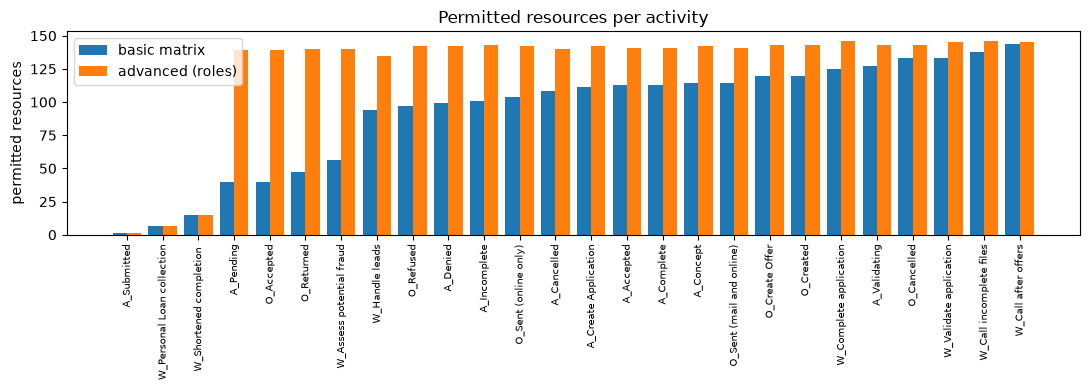

In [4]:
added = sum(len(adv_map.get(a, set()) - basic.who_can(a)) for a in activities)
print('extra (activity, resource) permissions added by roles:', added)

adv_counts = {a: len(adv_map.get(a, set())) for a in activities}
order = sorted(activities, key=lambda a: basic_counts[a])
x = np.arange(len(order))
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - 0.2, [basic_counts[a] for a in order], width=0.4, label='basic matrix')
ax.bar(x + 0.2, [adv_counts[a] for a in order], width=0.4, label='advanced (roles)')
ax.set_xticks(x); ax.set_xticklabels(order, rotation=90, fontsize=7)
ax.set_ylabel('permitted resources'); ax.legend(); ax.set_title('Permitted resources per activity')
fig.tight_layout(); fig.savefig('../results/permissions_basic_vs_advanced.png', dpi=120)
print('saved ../results/permissions_basic_vs_advanced.png')

## Validation: are the added permissions realistic?
A temporal split (train on the first 70%, test on the last 30%) measures how many held-out (activity, resource) assignments each model already permits. The role generalization is deliberately permissive: the committed model is near-saturating and its held-out recall barely exceeds the plain matrix, so the additions model within-role interchangeability rather than validated future assignments. The observed-performer floor is what guarantees coverage. A light n_groups sensitivity (fallback miner) shows the role count is not brittle.

In [5]:
# Validation: temporal split, saturation, n_groups sensitivity
R = df['org:resource'].nunique()

# (a) are the added permissions realistic? temporal split: roles on first 70%, recall on last 30%
order = np.argsort(pd.to_datetime(df['time:timestamp'], utc=True).values, kind='stable')
dfs = df.iloc[order]; cut = int(0.7 * len(dfs)); train, test = dfs.iloc[:cut], dfs.iloc[cut:]
basic_tr = PermissionModel(train, artifact_path=None)
adv_tr = {a: set(rs) for a, rs in role_discovery.discover_roles(train, n_groups=14)[0].items()}
pairs = test[['concept:name', 'org:resource']].dropna().astype(str).drop_duplicates()
tp = list(zip(pairs['concept:name'], pairs['org:resource']))
rec_basic = np.mean([r in basic_tr.who_can(a) for a, r in tp])
rec_adv = np.mean([r in adv_tr.get(a, set()) for a, r in tp])
print('held-out (act,res) recall over %d test pairs | basic: %.1f%% | roles: %.1f%%'
      % (len(tp), 100*rec_basic, 100*rec_adv))

# (b) saturation of the committed advanced model (permissive generalization)
sat = sum(len(adv_map[a]) >= 140 for a in adv_map)
fill = sum(len(v) for v in adv_map.values()) / (len(adv_map) * R)
print('saturation | %d/%d activities permit >=140/%d resources, matrix fill %.0f%%'
      % (sat, len(adv_map), R, 100*fill))

# (c) n_groups sensitivity (fallback role miner on the full log)
print('n_groups sensitivity (fallback):')
for ng in [8, 14, 20]:
    md = {a: set(rs) for a, rs in role_discovery.discover_roles(df, n_groups=ng)[0].items()}
    add = sum(len(md.get(a, set()) - basic.who_can(a)) for a in activities)
    dd = sum(len(v) for v in md.values()) / (len(activities) * R)
    print('  n_groups=%2d -> +%d added, density %.0f%%' % (ng, add, 100*dd))

held-out (act,res) recall over 1735 test pairs | basic: 77.4% | roles: 77.8%
saturation | 20/26 activities permit >=140/149 resources, matrix fill 85%
n_groups sensitivity (fallback):
  n_groups= 8 -> +39 added, density 63%


  n_groups=14 -> +15 added, density 63%
  n_groups=20 -> +7 added, density 62%


**Result:** OrdinoR groups the 149 resources into 14 roles and assigns each role the execution contexts (activities) its members perform. 